### Improving reasoning-with inference time scaling

* Note: Our base-model, here means(already instruction-finetuned model)

In [1]:
from pathlib import Path
import sys
import torch

ROOT_DIR = Path.cwd().parent  # Get parent of current directory
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))


from evaluating_reasoning_models.model_and_tokenizer import load_model_and_tokenizer

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    use_compile=False
)



Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [2]:
from evaluating_reasoning_models.evaluating_reasoning_models import generate_text_stream_with_kv_cache
from evaluating_reasoning_models.evaluating_reasoning_models import render_prompt


In [3]:
raw_prompt = ("Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?")

prompt = render_prompt(raw_prompt)

print(prompt)

You are a helpful math assistant.

Solve the problem step by step.
The last line of your response should contain only the final answer inside \boxed{}.

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:



In [4]:
from evaluating_reasoning_models.evaluating_reasoning_models import (
    has_complete_boxed_answer,
)


def generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens,
    verbose=False,
    generate_func=None,
    stop_after_boxed=True,
    stop_texts=("\nQuestion:", "\nAnswer:"),
    **generate_kwargs,
):
    if generate_func is None:
        generate_func = generate_text_stream_with_kv_cache

    generated_ids = []
    generated_text = ""

    for token in generate_func(
        prompt=prompt,
        model=model,
        tokenizer=tokenizer,
        device=device,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        **generate_kwargs,
    ):

        token_id = token.squeeze(0).item()
        generated_ids.append(token_id)

        token_text = tokenizer.decode([token_id])
        generated_text += token_text

        if verbose:
            print(
                token_text,
                end="",
                flush=True,
            )

        if stop_after_boxed and has_complete_boxed_answer(
            generated_text
        ):
            break

        """if stop_texts and any(stop_text in generated_text for stop_text in stop_texts):
            break"""

    return generated_text

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
response = generate_text_stream_concat_flex(model, 
    tokenizer, 
    prompt, 
    device, 
    max_new_tokens=200, 
    verbose=True, 
    generate_func=generate_text_stream_with_kv_cache)

\boxed{x=12}



### Now, using Chain-of-thought prompt ---for better response

In [6]:
prompt_cot = prompt + " \n\nExplain step step by step."

response = generate_text_stream_concat_flex(model, 
    tokenizer, 
    prompt_cot, 
    device, 
    max_new_tokens=700, 
    verbose=True)

 Let me think... First, I need

 to solve the equation $3x - 9 = x + 37$ for x. Then, once I find x, I can put it in the box.

Okay, let's start by writing down the equation:

$3x - 9 = x + 37$

Now, to solve for x, I need to isolate it on one side. Let me subtract x from both sides to get rid of x on the right. So:

$3x - 9 - x = x + 37 - x$

Simplifying both sides:

$2x - 9 = 37$

Now, I need to get rid of the -9 on the left side. I can add 9 to both sides:

$2x - 9 + 9 = 37 + 9$

Simplifying:

$2x = 46$

Now, to solve for x, I divide both sides by 2:

$\frac{2x}{2} = \frac{46}{2}$

Simplifying:

$x = 23$

So, the value of x is 23. Let me check my work to make sure I didn't make any mistakes. Plugging x = 23 back into the original equation:

Left side: $3(23) - 9 = 69 - 9 = 60$

Right side: $23 + 37 = 60$

Yes, both sides equal 60, so the solution is correct.

Final answer: \boxed{23}


### Controlling output diversity with temperature scaling
* starting with temperature scaling

* ok, now  ---> process of selecting the token

In [7]:
### let's see, how we can get the next token...
prompt_example = "large language models are"
# first will convert the input prompt -> to ids
input_ids = torch.tensor(tokenizer.encode(prompt_example), device=device).unsqueeze(0)

print(input_ids)

tensor([[16767,  4128,  4119,   525]], device='cuda:0')


In [8]:
with torch.inference_mode():
    next_token_logits = model(input_ids,)[:, -1]

print(next_token_logits.shape)  ##  [batch, vocab_size]



torch.Size([1, 151936])


In [9]:
next_token = torch.argmax(next_token_logits)  ## with highest logit score

print(f"This is the token: {tokenizer.decode([next_token])}")
print(f"This is the token id: {next_token}")

This is the token:  trained
This is the token id: 16176


* now let's visualize this, we are not taking entire vocab, but only 100 tokens---> word "trained" is between

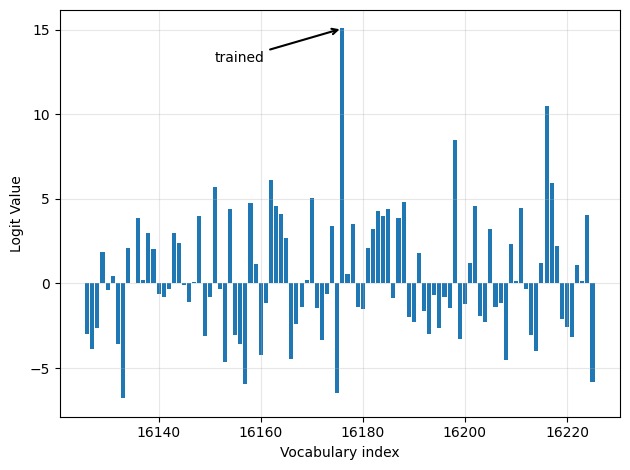

In [10]:
import matplotlib.pyplot as plt

def plot_scores_bar(next_token_logits, start=16126, end=16226, arrow=True, ylabel="Logit Value"):

    ## vocab subsection(instead of all vocab---> use only 100 tokens, to visualize)
    x = torch.arange(start, end)

    # Select logits for the first sequence in the batch and the token IDs
    # in the range [start:end], then convert to float32 and move to CPU. [we have given token in this range of vocab]
    logits_section = next_token_logits[0, start:end].float().cpu()    

    ## plot logits
    plt.bar(x, logits_section)
    plt.xlabel("Vocabulary index")
    plt.ylabel(ylabel)

    # Highlight max logit
    if arrow:
        max_idx = torch.argmax(logits_section)
        plt.annotate(
            "trained",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={
                "facecolor": "black", "arrowstyle": "->", "lw": 1.5
            },
            fontsize=10,
        )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_scores_bar(next_token_logits)

### Rescaling token scores(logits) with a temperature parameter

In [11]:
def scale_logits_by_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    return logits / temperature

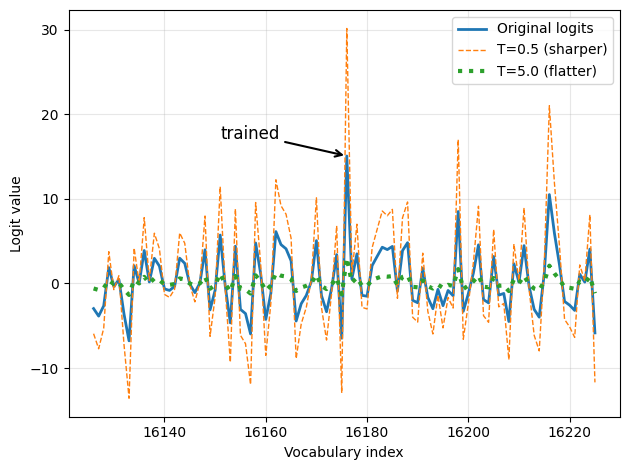

In [16]:
def plot_logits_with_temperature(
    next_token_logits, start=16_126, end=16_226,
    temps=(0.5, 5.0),
):
    x = torch.arange(start, end)
    logits_orig = next_token_logits[0, start:end].float().cpu()

    # Apply temperature scaling
    logits_scaled = [
        scale_logits_by_temperature(logits_orig, T) for T in temps
    ]
    # Plot logits
    plt.plot(x, logits_orig, label="Original logits", lw=2)
    plt.plot(
        x, logits_scaled[0],
        label=f"T={temps[0]} (sharper)", ls="--", lw=1
    )
    plt.plot(
        x, logits_scaled[1],
        label=f"T={temps[1]} (flatter)", ls=":", lw=3
    )

    # Highlight max logit
    max_idx = torch.argmax(logits_orig)
    plt.annotate(
        "trained",
        xy=(x[max_idx], logits_orig[max_idx]),
        xytext=(x[max_idx] - 25, logits_orig[max_idx] + 2),
        arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
        fontsize=12,
    )

    plt.xlabel("Vocabulary index")
    plt.ylabel("Logit value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_logits_with_temperature(
    next_token_logits,
    temps=(0.5, 5.0)
)

### Sampling the next token from a probability distribution

In [ ]:
# Rescale next-token scores
rescaled_logits = scale_logits_by_temperature(next_token_logits, 5.0)

# Convert rescaled logits into probability scores
next_token_probas = torch.softmax(
    rescaled_logits, dim=-1
)

print("Probability sum:", torch.sum(next_token_probas))

Probability sum: tensor(1., device='cuda:0', dtype=torch.bfloat16)


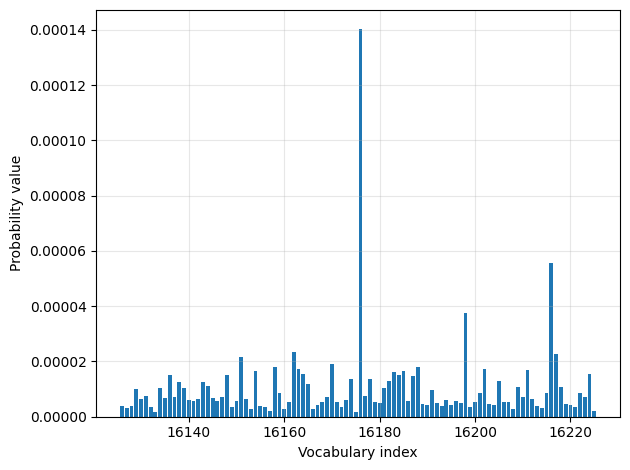

In [14]:
plot_scores_bar(
    next_token_probas, arrow=False, ylabel="Probability value"
)

In [15]:
print("Token ID 16,176 probability:", next_token_probas[:, 16176])

Token ID 16,176 probability: tensor([0.0001], device='cuda:0', dtype=torch.bfloat16)


In [17]:
print("Highest probability:", max(next_token_probas.squeeze(0)))

Highest probability: tensor(0.0001, device='cuda:0', dtype=torch.bfloat16)


In [18]:
# Step 3.4: Sample token according to probabilities
torch.manual_seed(123)
print(
    "Sampled token:",
    torch.multinomial(next_token_probas.cpu(), num_samples=1)
)

Sampled token: tensor([[141943]])


In [19]:
print(tokenizer.decode([141943]))

ämp


In [20]:
def count_samples(probas, num_samples=1000, threshold=1, tokenizer=None):
    # Draw samples according to probabilities
    samples = torch.multinomial(
        probas.cpu(), num_samples=num_samples, replacement=True
    )
    
    # Count how often each index was selected
    counts = torch.bincount(samples.squeeze(0), minlength=1)
    
    # Print results
    for i, c in enumerate(counts):
        if c > threshold:
            if tokenizer is None:
                print(f"Vocab index {i}: {c.item()}x")
            else:
                print(f"'{tokenizer.decode([i])}': {c.item()}x")

In [21]:
torch.manual_seed(123)
count_samples(next_token_probas, tokenizer=tokenizer)

' the': 2x
' only': 2x
' known': 2x
' namely': 2x
' intensive': 2x


' requestId': 2x
' нам': 2x


In [23]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' the': 2x
' not': 4x
' used': 55x
' very': 19x
' being': 14x
' great': 14x
' already': 3x
' able': 4x
' often': 4x
' known': 2x
' currently': 2x
' usually': 2x
' particularly': 2x
' generally': 5x
' becoming': 8x
' typically': 25x
' capable': 21x
' widely': 2x
' trained': 806x
' commonly': 2x


In [24]:
print(probas_lowT[0, 16176])

tensor(0.8008, device='cuda:0', dtype=torch.bfloat16)


### adding temperature scaling to the text generation function

In [33]:
# Exercise 2.2 Appendix B
from base_model.qwen import KVCache

@torch.inference_mode()
def generate_text_temp_stream_cache(
    model,
    prompt,
    tokenizer,
    device,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.1
):

    token_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)
    
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):


        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)


        if (eos_token_id is not None
                and torch.all(next_token == eos_token_id)):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [34]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_temp_stream_cache,
    temperature=1.1
)

\boxed{x = 5}


### Balancing diversity and coherence with top-p sampling

* selecting a subset of top-p tokens

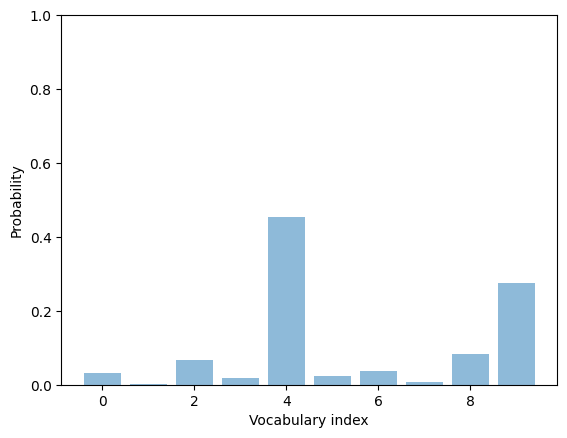

In [ ]:
#  Get logits (here: use toy logits for 10 tokens)
toy_logits = torch.tensor(
    [-0.7, -3.0, 0.1, -1.2, 2.0, -1.0, -0.5, -2.0, 0.3, 1.5]
)

# Apply temperature scaling
toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1.0)

# Convert to probabilities
toy_probas = torch.softmax(toy_logits_scaled, dim=-1)

plt.bar(
    torch.arange(len(toy_logits_scaled)), toy_probas,
    alpha=0.5
)

plt.ylim([0, 1])
plt.xlabel("Vocabulary index")
plt.ylabel("Probability")
plt.show()

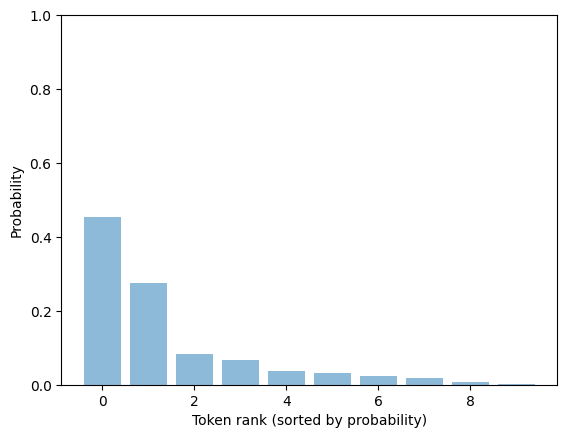

In [36]:

# Step 4.1: Sort by descending probability
sorted_probas, sorted_idx = torch.sort(toy_probas, descending=True)

# Step 4.2: Compute cumulative sum
cumsum = torch.cumsum(sorted_probas, dim=-1)

plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas, 
        alpha=0.5
)


plt.ylim([0, 1])
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.show()

### adding a top-p filter to the text generation function

In [37]:
def top_p_filter(probas, top_p):
    if top_p is None or top_p >= 1.0:
        return probas

    # Step 4.1: Sort by descending probability
    sorted_probas, sorted_idx = torch.sort(probas, dim=1, descending=True)

    # Step 4.2: Cumulative sum
    cumprobas = torch.cumsum(sorted_probas, dim=1)

    # Step 4.3.1: Keep tokens where prefix cumulative mass (before token) is < top_p
    # Example: [0.5, 0.41, 0.09] with top_p=0.9 should keep the first two tokens
    prefix = cumprobas - sorted_probas   # cumulative mass before each token
    keep = prefix < top_p
    # Always keep at least one token (fallback for very small/non-positive top_p)
    keep[:, 0] = True    

    # Step 4.3.2: Zero out beyond cutoff
    kept_sorted = torch.where(
        keep, sorted_probas,
        torch.zeros_like(sorted_probas)
    )
    # Step 4.3.3: Map back to original order
    filtered = torch.zeros_like(probas).scatter(1, sorted_idx, kept_sorted)

    # Step 4.4: Renormalize to sum to 1
    denom = torch.sum(filtered, dim=1, keepdim=True).clamp_min(1e-12)
    return filtered / denom

In [38]:
with torch.inference_mode():
    next_token_logits = model(input_ids)[:, -1]
print(next_token_logits.shape)

torch.Size([1, 151936])


In [39]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' the': 2x
' not': 4x
' used': 55x
' very': 19x
' being': 14x
' great': 14x
' already': 3x
' able': 4x
' often': 4x
' known': 2x
' currently': 2x
' usually': 2x
' particularly': 2x
' generally': 5x
' becoming': 8x
' typically': 25x
' capable': 21x
' widely': 2x
' trained': 806x
' commonly': 2x


In [40]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.39), dim=-1
)
probas_lowT_filtered = top_p_filter(probas_lowT, top_p=0.8)

count_samples(probas_lowT_filtered, threshold=1, tokenizer=tokenizer)

' used': 96x
' typically': 45x
' trained': 859x


In [ ]:
@torch.inference_mode()
def generate_text_top_p_stream_cache(
    model,
    prompt,
    tokenizer, 
    device,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.1,
    top_p=None
):

    token_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):

        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)

            # (New) Step 4: Apply top-p filter to probabilities
            probas = top_p_filter(probas, top_p)            

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)

        if (eos_token_id is not None
                and torch.all(next_token == eos_token_id)):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [43]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.2,
    top_p=0.8, 
)

\boxed{x = 12}



### Improving response accuracy with self-consistency

In [37]:
# in this technique, we will ---> sample multiple reasoning traces
# with high-temperature and top-p, ---> then extract the final answer from each chain
# chooses the most frequent final answer

from evaluating_reasoning_models.evaluating_reasoning_models import extract_final_candidate
from collections import Counter

def self_consistency_vote(
    model, tokenizer, prompt, device,
    num_samples=10, temperature=0.8, top_p=0.9,
    max_new_tokens=2048, show_progress=True, show_long_answer=False, seed=None):

    full_answers, short_answers = [], []

    # sample multiple answers
    for i in range(num_samples):
        if seed is not None:
            torch.manual_seed(seed + i + 1)

        answer = generate_text_stream_concat_flex(
            model=model, tokenizer=tokenizer, prompt=prompt,
            device=device, max_new_tokens=max_new_tokens, verbose=show_long_answer,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature, top_p=top_p
        )

        # extract the final (short) answer from each answer
        short = extract_final_candidate(answer, fallback="number_then_full")

        full_answers.append(answer)
        short_answers.append(short)

        if show_progress:
            print(f"[Sample {i+1}/{num_samples}] -> {short!r}")

    ## choose the most frequent final answer (self-consistency vote)
    counts = Counter(short_answers)

    groups = {s: [] for s in counts}

    for idx, s in enumerate(short_answers):
        groups[s].append(idx)   ## adding indexes to list, where value appears

    mc = counts.most_common()  ## this will store the frequency count --> that how many times each value appears like [("42", 6)]

    if not mc:
        majority_winners, final_answer = [], None

    else:
        top_freq = mc[0][1]
        majority_winners = [s for s, f in mc if f == top_freq]
        final_answer = mc[0][0] if len(majority_winners) == 1 else None

    return {
        "full_answers": full_answers,
        "short_answers": short_answers,
        "counts": dict(counts),
        "groups": groups,
        "majority_winners": majority_winners,
        "final_answer": final_answer
    }

* notes from raschka's notebook
- if all (long) answers look nearly identical, increase temperature gently to increase diversity
- if (long) answers look off, decrease temperature

In [38]:
results = self_consistency_vote(
    model, tokenizer,
    prompt, device=device,
    num_samples=7, temperature=0.8,
    top_p=0.9, max_new_tokens=2048,
    seed=123, show_progress=True,
)

[Sample 1/7] -> 'x=21'


[Sample 2/7] -> '13'
[Sample 3/7] -> '22'
[Sample 4/7] -> '12'
[Sample 5/7] -> '14'
[Sample 6/7] -> '19'
[Sample 7/7] -> '12'


In [39]:
print(results["final_answer"])

12


In [40]:
print(results["full_answers"])

['\\boxed{x=21}\n\n', '\\boxed{13}\n\n', '\\boxed{22}\n\n', '\\boxed{12}\n\n', '\\boxed{14}\n\n', '\\boxed{19}\n\n', '\\boxed{12}\n\n']


In [ ]:
## testing temperature at 0.5
results = self_consistency_vote(
    model, tokenizer,
    prompt + "\n\nExplain step by step.",  ## using chain-of-thought
    device=device,
    num_samples=7, temperature=0.5,
    top_p=0.9, max_new_tokens=2048,
    seed=123, show_progress=True
)

[Sample 1/7] -> '83'
[Sample 2/7] -> 'Please put your answer inside \\boxed{}'
[Sample 3/7] -> '10'
[Sample 4/7] -> '83'
[Sample 5/7] -> '83'
[Sample 6/7] -> '37'
[Sample 7/7] -> '83'


* here used temperature=0.5, and in "text_generation" function stop texts was disabled...
* model was still giving some garbage output-->

In [44]:
print(results["full_answers"][0])   ## after commenting the stop_answeer --- code in text_generation function

:

Step 1: The problem says that half the value of $3x - 9$ is $x + 37$. So, we can write this as an equation: $ \frac{1}{2}(3x - 9) = x + 37 $.

Step 2: Solve for x by multiplying both sides by 2 to eliminate the fraction. $3x - 9 = 2x + 74$.

Step 3: Subtract 2x from both sides to isolate the variable. $3x - 2x - 9 = 74$.

Step 4: Simplify the left side. $x - 9 = 74$.

Step 5: Add 9 to both sides to solve for x. $x = 83$.

Answer: \boxed{83}



### Self-Consistency Decoding

Used **Chain of Thought (CoT)** prompting so the model explains its reasoning step by step before producing the final answer.

**Issue:** The generation was stopping too early because of:

```python
if stop_texts and any(stop_text in generated_text for stop_text in stop_texts):
    break
```

I temporarily commented it out, which allowed the model to generate the complete reasoning trace and the full `\boxed{...}` answer.

**Temperature tuning:** With `temperature=0.8`, the model produced many noisy and inconsistent answers. I reduced it to `0.5`, which made the generations more stable while still preserving diversity.

**Result:** After using CoT reasoning, disabling premature stopping, and lowering the temperature, the self-consistency vote successfully converged on the correct answer, with the majority answer appearing **4 times**.

### now going to evaluate

## Final evaluation runs

Run a small MATH-500 subset first so generation settings are easy to verify before scaling up. 
* in both, base and reasoning mode

In [45]:
from pathlib import Path
import importlib

from evaluating_reasoning_models.load_math_500 import load_math500_test
import evaluating_reasoning_models.evaluating_reasoning_models as eval_math

eval_math = importlib.reload(eval_math)

# The evaluator expects a concat-style generator. Patch it to the notebook wrapper so
# it uses the currently selected decoding function and avoids stale helper names.
eval_math.generate_text_stream_concat = generate_text_stream_concat_flex
evaluate_math500_stream = eval_math.evaluate_math500_stream

math_data = load_math500_test()
len(math_data)

500

In [46]:
math_data[1]

{'problem': 'Define\n\\[p = \\sum_{k = 1}^\\infty \\frac{1}{k^2} \\quad \\text{and} \\quad q = \\sum_{k = 1}^\\infty \\frac{1}{k^3}.\\]Find a way to write\n\\[\\sum_{j = 1}^\\infty \\sum_{k = 1}^\\infty \\frac{1}{(j + k)^3}\\]in terms of $p$ and $q.$',
 'solution': 'We count the number of times $\\frac{1}{n^3}$ appears in the sum\n\\[\\sum_{j = 1}^\\infty \\sum_{k = 1}^\\infty \\frac{1}{(j + k)^3},\\]where $n$ is a fixed positive integer.  (In other words, we are conditioning the sum on $j + k$.)  We get a term of $\\frac{1}{n^3}$ each time $j + k = n.$  The pairs $(j,k)$ that work are $(1,n - 1),$ $(2,n - 2),$ $\\dots,$ $(n - 1,1),$ for a total of $n - 1$ pairs.  Therefore,\n\\begin{align*}\n\\sum_{j = 1}^\\infty \\sum_{k = 1}^\\infty \\frac{1}{(j + k)^3} &= \\sum_{n = 1}^\\infty \\frac{n - 1}{n^3} \\\\\n&= \\sum_{n = 1}^\\infty \\left( \\frac{n}{n^3} - \\frac{1}{n^3} \\right) \\\\\n&= \\sum_{n = 1}^\\infty \\left( \\frac{1}{n^2} - \\frac{1}{n^3} \\right) \\\\\n&= \\sum_{n = 1}^\\inft

### Evaluating on Math500 --> using all of these approachs, CoT, Temperature, Top-p, Self-consistency in both base and reasoning mode.

In [47]:
from pathlib import Path
import json
import time

from evaluating_reasoning_models.evaluating_reasoning_models import (
    eta_progress_message,
    extract_final_candidate,
    grade_answer,
    render_prompt,
)

device = "cuda" if torch.cuda.is_available() else "cpu"


### Evaluation

Set `prompt_suffix` for CoT prompting. Set `num_samples > 1` to run top-p self-consistency, `top_p` is already there, and `temperature` is already there.

In [49]:
## written by codex here..

def evaluate_math500_notebook(
    model,
    tokenizer,
    device,
    math_data,
    out_path,
    max_new_tokens=2048,
    prompt_suffix="\n\nExplain step by step.",
    num_samples=1,
    temperature=0.2,
    top_p=0.9,
    seed=123,
    verbose=False,
):
    out_path = Path(out_path)
    num_examples = len(math_data)
    num_correct = 0
    total_len = 0
    start_time = time.time()

    with out_path.open("w", encoding="utf-8") as f:
        for i, row in enumerate(math_data, start=1):
            prompt = render_prompt(row["problem"]) + prompt_suffix

            if num_samples == 1:
                generated_text = generate_text_stream_concat_flex(
                    model=model,
                    tokenizer=tokenizer,
                    prompt=prompt,
                    device=device,
                    max_new_tokens=max_new_tokens,
                    verbose=verbose,
                    generate_func=generate_text_stream_with_kv_cache,
                )
                extracted = extract_final_candidate(generated_text)
                samples = None
            else:
                vote = self_consistency_vote(
                    model=model,
                    tokenizer=tokenizer,
                    prompt=prompt,
                    device=device,
                    num_samples=num_samples,
                    temperature=temperature,
                    top_p=top_p,
                    max_new_tokens=max_new_tokens,
                    show_progress=False,
                    show_long_answer=verbose,
                    seed=seed + i,
                )
                extracted = vote["final_answer"] or vote["majority_winners"][0]
                sample_idx = vote["groups"][extracted][0]
                generated_text = vote["full_answers"][sample_idx]
                samples = vote["short_answers"]

            is_correct = grade_answer(extracted, row["answer"])
            num_correct += int(is_correct)
            total_len += len(tokenizer.encode(generated_text))

            record = {
                "index": i,
                "problem": row["problem"],
                "gtruth_answer": row["answer"],
                "generated_text": generated_text,
                "extracted": extracted,
                "correct": bool(is_correct),
                "samples": samples,
            }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

            print(eta_progress_message(i, num_examples, start_time), end="\r", flush=True)

    seconds = time.time() - start_time
    acc = num_correct / num_examples if num_examples else 0.0

    print(f"\n\nAccuracy: {acc*100:.1f}% ({num_correct}/{num_examples})")
    print(f"Total time: {seconds/60:.1f} minutes")
    print(f"Average response length: {total_len/num_examples:.1f} tokens")
    print(f"Results saved to: {out_path}")

    return num_correct, num_examples, acc

===================================================================================================

Eval 1: In base mode → using temperature=0.2, top-p sampling, and Chain-of-Thought (CoT) prompting.

===================================================================================================

In [50]:
which_model = "base"
eval_subset = math_data[:20]
max_new_tokens = 2048

print("Model:", which_model)
print("Device:", device)
print("Examples:", len(eval_subset))

num_correct, num_examples, acc = evaluate_math500_notebook(
    model=model,
    tokenizer=tokenizer,
    device=device,
    math_data=eval_subset,
    out_path=f"math500-{which_model}-{device}-cot-greedy.jsonl",
    max_new_tokens=max_new_tokens,
    prompt_suffix="\n\nExplain step by step.",
    num_samples=1,
    verbose=False,
)

num_correct, num_examples, acc

Model: base
Device: cuda
Examples: 20


Progress: 20/20 | ETA: 00s        

Accuracy: 15.0% (3/20)
Total time: 5.8 minutes
Average response length: 493.1 tokens
Results saved to: math500-base-cuda-cot-greedy.jsonl


(3, 20, 0.15)

===================================================================================================

** Eval 1 Result: 
Base Model Results:
   - Correctly solved: 3 / 20 problems
   - Accuracy: 15.0%
   - Runtime: ~5.8 minutes for 20 problems
   - Hardware: Tesla T4 GPU

===================================================================================================

===================================================================================================

Eval 2: In base mode → using temperature=0.2, top-p sampling, Chain-of-Thought (CoT) prompting and Self-Consistency Vote (n_samples=7)

===================================================================================================

In [51]:
which_model = "base"
eval_subset = math_data[:20]
max_new_tokens = 2048

print("Model:", which_model)
print("Device:", device)
print("Examples:", len(eval_subset))


num_correct, num_examples, acc = evaluate_math500_notebook(
     model=model,
     tokenizer=tokenizer,
     device=device,
     math_data=math_data[:20],
     out_path=f"math500-{which_model}-{device}-cot-self-consistency.jsonl",
     max_new_tokens=2048,
     prompt_suffix="\n\nExplain step by step.",
     num_samples=7,
     temperature=0.2,
     top_p=0.9,
     seed=123,
     verbose=False,
 )

num_correct, num_examples, acc

Model: base
Device: cuda
Examples: 20


Progress: 20/20 | ETA: 00s        

Accuracy: 20.0% (4/20)
Total time: 36.6 minutes
Average response length: 238.0 tokens
Results saved to: math500-base-cuda-cot-self-consistency.jsonl


(4, 20, 0.2)

===================================================================================================

** Eval 2 Result: 
Base Model Results:
   - Correctly solved: 4 / 20 problems
   - Accuracy: 20.0%
   - Runtime: ~36.6 minutes for 20 problems
   - Hardware: Tesla T4 GPU

===================================================================================================

### Self-Consistency Results

Self-consistency voting improved accuracy from **15.0%** to **20.0%** on the first 20 MATH-500 problems.

However, the gain came at a substantial computational cost, increasing runtime from approximately **5.8 minutes** to **36.6 minutes** on a **Tesla T4 GPU**.

This suggests that self-consistency can recover some correct answers that already exist within the model's reasoning distribution, but provides limited benefit when the underlying base model lacks the reasoning capability required to solve the problem.

| Configuration | Correct | Accuracy | Runtime |
|--------------|---------|----------|---------|
| CoT + Temperature + Top-p | 3 / 20 | 15.0% | ~5.8 min |
| CoT + Temperature + Top-p + Self-Consistency (n=7) | 4 / 20 | 20.0% | ~36.6 min |

**Key Takeaway:** While self-consistency improved performance by one additional correct solution, the improvement was relatively small compared to the significant increase in inference cost. This highlights an important limitation of inference-time scaling: it can amplify existing reasoning capabilities but cannot compensate for a lack of underlying reasoning ability in the base model.

===================================================================================================

Eval 3: In reasoning mode → using temperature=0.2, top-p sampling, and Chain-of-Thought (CoT) prompting.

===================================================================================================

In [52]:
which_model = "reasoning"
eval_subset = math_data[:20]
max_new_tokens = 2048

print("Model:", which_model)
print("Device:", device)
print("Examples:", len(eval_subset))


num_correct, num_examples, acc = evaluate_math500_notebook(
     model=model,
     tokenizer=tokenizer,
     device=device,
     math_data=math_data[:20],
     out_path=f"math500-{which_model}-{device}-cot-self-consistency.jsonl",
     max_new_tokens=2048,
     prompt_suffix="\n\nExplain step by step.",
     num_samples=1,
     temperature=0.2,
     top_p=0.9,
     seed=123,
     verbose=False,
 )

num_correct, num_examples, acc

Model: reasoning
Device: cuda
Examples: 20


Progress: 20/20 | ETA: 00s        

Accuracy: 15.0% (3/20)
Total time: 5.8 minutes
Average response length: 493.1 tokens
Results saved to: math500-reasoning-cuda-cot-self-consistency.jsonl


(3, 20, 0.15)

===================================================================================================

** Eval 3 Result: 
Reasoning Model Results:
   - Correctly solved: 3 / 20 problems
   - Accuracy: 15.0%
   - Runtime: ~5.8 minutes for 20 problems
   - Hardware: Tesla T4 GPU

===================================================================================================

### Key Observation

Reasoning mode generated substantially longer reasoning traces (~493 tokens on average) but did not improve accuracy over the base configuration.

Together with the self-consistency results, this suggests that inference-time scaling can amplify existing reasoning capabilities, but cannot create reasoning skills that are not already present in the model.

## Final Conclusions

Across all experiments, the model showed limited mathematical reasoning ability on the first 20 problems of MATH-500.

Adding Chain-of-Thought (CoT) prompting encouraged the model to generate longer reasoning traces, while self-consistency voting provided a small improvement in accuracy (15% → 20%). However, these gains came at a significantly higher computational cost.

Manual inspection of the generations revealed that the model could occasionally solve straightforward algebra, arithmetic, and geometry problems correctly. At the same time, it frequently exhibited failure modes such as:

- Producing reasoning-like text without reaching the correct solution.
- Entering repetitive reasoning loops.
- Following instructions superficially rather than solving the problem.
- Making errors in multi-step mathematical reasoning.

Importantly, no major generation bug was observed. The decoding pipeline, answer extraction, and evaluation procedure behaved as expected. The results therefore appear to reflect the limitations of the underlying model rather than issues in the inference pipeline.

Overall, these experiments highlight an important limitation of inference-time scaling: techniques such as CoT prompting and self-consistency can amplify existing reasoning capabilities, but they cannot create reasoning skills that are not already present in the model. Meaningful improvements in mathematical reasoning are therefore more likely to come from post-training methods such as supervised fine-tuning, preference optimization, and reinforcement learning rather than from decoding strategies alone.

In [54]:
### end ...